In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import torch
import random
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
random.seed(255)

In [ ]:
db = sqlite3.connect("/content/drive/MyDrive/Datasets/Cleaned/dat490.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", db)
print(tables)
print(pd.read_sql("SELECT * FROM poverty_estimates;", db).columns)
df_combined = pd.read_sql("""
    SELECT *
    FROM public_schools ps
    LEFT JOIN poverty_estimates pe
      ON ps.school_id = pe.school_id
    LEFT JOIN math m
      ON ps.school_id = m.school_id
    LEFT JOIN reading_language_arts rla
      ON ps.school_id = rla.school_id
    LEFT JOIN graduation_rates gr
      ON ps.school_id = gr.school_id
""", db)

df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

df_public = pd.read_sql("""
    SELECT *
    FROM public_schools
""", db)

df_poverty = pd.read_sql("""
    SELECT *
    FROM poverty_estimates
""", db)

df_math = pd.read_sql("""
    SELECT *
    FROM math
""", db)

df_rla = pd.read_sql("""
    SELECT *
    FROM reading_language_arts
""", db)

df_grad = pd.read_sql("""
    SELECT *
    FROM graduation_rates
""", db)

for i, item in enumerate(df_combined.columns):
  print(item, end = ',')
  if i % 10 == 0:
    print()

                    name
0         public_schools
1      poverty_estimates
2                   math
3  reading_language_arts
4       graduation_rates
Index(['school_id', 'school_name', 'income_to_poverty_ratio_estimate',
       'income_to_poverty_ratio_standard_error'],
      dtype='object')
x,
y,object_id,school_id,servey_year,state,district_id,local_education_agency,school_name,street_1,street_2,
city,zip,zip4,phone,charter,magnet,virtual,lowest_grade_level,highest_grade_level,school_level,
title_one,status,school_type,operational,local_type,conty_name,total_free_reduced_lunch,free_lunch,reduced_lunch,prek_students,
kindergarden_students,first_students,second_students,third_students,fourth_students,fith_students,sixth_students,seventh_students,eighth_students,nineth_students,
tenth_students,eleventh_students,twelth_students,thirteenth_students,ungraded_students,alternative_education,total_male_students,total_female_students,total_students,facualty_fulltime_equivilant,
student_teacher

In [ ]:
df_combined_math = pd.read_sql("""
    SELECT *
    FROM public_schools ps
    LEFT JOIN poverty_estimates pe
      ON ps.school_id = pe.school_id
    LEFT JOIN math m
      ON ps.school_id = m.school_id
""", db)

df_combined_math = df_combined.loc[:, ~df_combined.columns.duplicated()]


In [ ]:
print(df_combined_math.head())


            x          y  object_id    school_id servey_year state  \
0 -149.357788  61.627075          1  20051000480   2018-2019    AK   
1 -156.754211  71.300476          2  20061000470   2018-2019    AK   
2 -151.070190  60.491516          3  20039000448   2018-2019    AK   
3 -151.279114  60.568298          4  20039000463   2018-2019    AK   
4 -151.232300  60.567078          5  20039000513   2018-2019    AK   

   district_id                     local_education_agency  \
0       200510  Matanuska-Susitna Borough School District   
1       200610        North Slope Borough School District   
2       200390    Kenai Peninsula Borough School District   
3       200390    Kenai Peninsula Borough School District   
4       200390    Kenai Peninsula Borough School District   

                             school_name            street_1  ...  \
0                   John Shaw Elementary  3750 E Paradise Ln  ...   
1               Kiita Learning Community      5246 Karluk St  ...   
2    

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0.5, 0, '% American Indian'),
  Text(1.5, 0, '% Asian'),
  Text(2.5, 0, '% Black'),
  Text(3.5, 0, '% Hispanic'),
  Text(4.5, 0, '% Native Hawaiian/Pacific Islander'),
  Text(5.5, 0, '% Two or More Races'),
  Text(6.5, 0, '% White')])

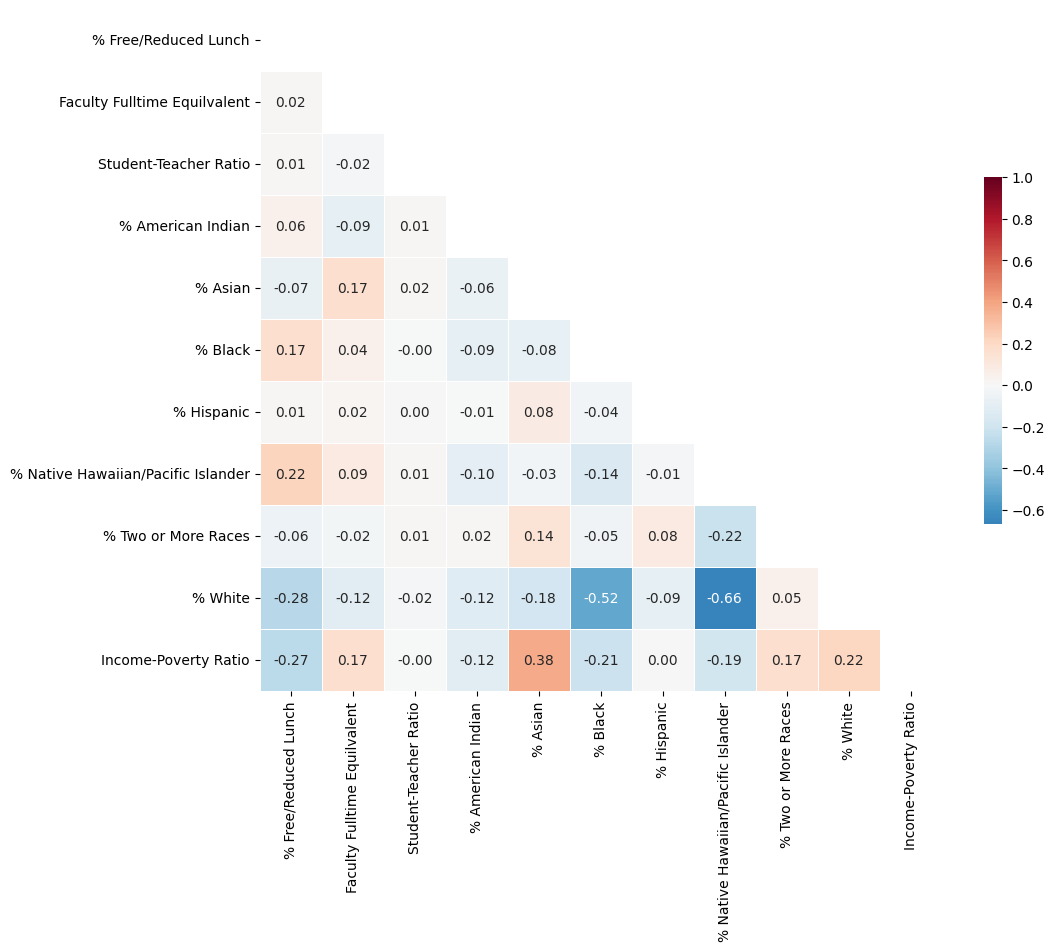

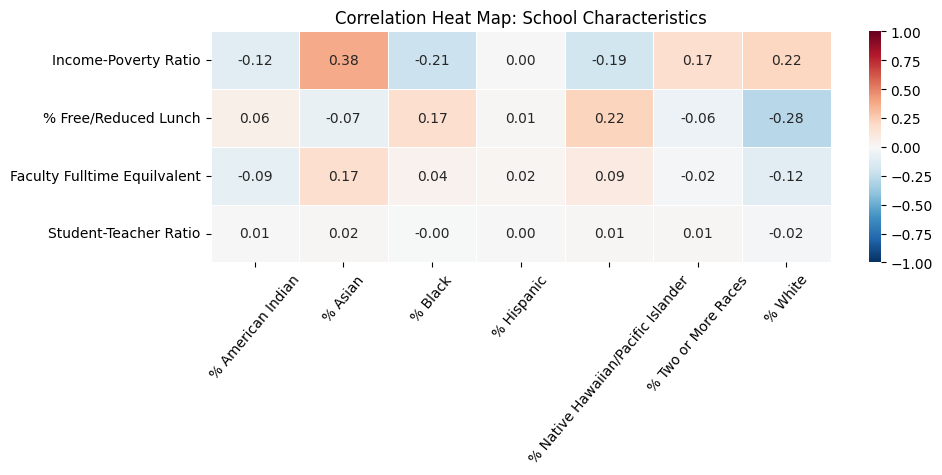

In [ ]:
df_combined["pct_american_indian"] = (
    df_combined["american_indian_alaska_native_total"] /
    df_combined["total_students"]
)

df_combined["pct_asian"] = (
    df_combined["asian_total"] /
    df_combined["total_students"]
)

df_combined["pct_black"] = (
    df_combined["black_total"] /
    df_combined["total_students"]
)

df_combined["pct_hispanic"] = (
    df_combined["hispanic_total"] /
    df_combined["total_students"]
)

df_combined["pct_native_hawaiian_pacific_islander"] = (
    df_combined["native_hawaiian_pacific_islander_total"] /
    df_combined["total_students"]
)

df_combined["pct_two_or_more"] = (
    df_combined["two_or_more_race_total"] /
    df_combined["total_students"]
)

df_combined["pct_white"] = (
    df_combined["white_total"] /
    df_combined["total_students"]
)

df_combined["pct_total_free_reduced_lunch"] = (
    df_combined["total_free_reduced_lunch"] /
    df_combined["total_students"]
)

df_test = df_combined[['pct_total_free_reduced_lunch', 'facualty_fulltime_equivilant', 'student_teacher_ratio',
                       'pct_american_indian', 'pct_asian', 'pct_black', 'pct_hispanic',
                       'pct_native_hawaiian_pacific_islander', 'pct_two_or_more', 'pct_white', 'income_to_poverty_ratio_estimate']]

df_test = df_test.rename(columns={
    'pct_total_free_reduced_lunch': '% Free/Reduced Lunch',
    'facualty_fulltime_equivilant': 'Faculty Fulltime Equilvalent',
    'student_teacher_ratio': 'Student-Teacher Ratio',
    'pct_american_indian': '% American Indian',
    'pct_asian': '% Asian',
    'pct_black': '% Black',
    'pct_hispanic': '% Hispanic',
    'pct_native_hawaiian_pacific_islander': '% Native Hawaiian/Pacific Islander',
    'pct_two_or_more': '% Two or More Races',
    'pct_white': '% White',
    'income_to_poverty_ratio_estimate': 'Income-Poverty Ratio'
})



corr_matrix = df_test.corr()
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix,
            mask=mask,
            cmap="RdBu_r",
            vmax=1,
            center=0,
            square=True,
            linewidths=.5,
            annot=True,
            fmt=".2f",
            cbar_kws={"shrink": .5})


corr_matrix = df_test.corr(numeric_only=True)

corr_subset = corr_matrix.loc[
    ['Income-Poverty Ratio', '% Free/Reduced Lunch',  'Faculty Fulltime Equilvalent', 'Student-Teacher Ratio'],
    ['% American Indian', '% Asian',
    '% Black',
    '% Hispanic',
    '% Native Hawaiian/Pacific Islander',
    '% Two or More Races',
    '% White']]

plt.figure(figsize=(10,3))

sns.heatmap(
    corr_subset,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Correlation Heat Map: School Characteristics")
plt.xticks(rotation=50)

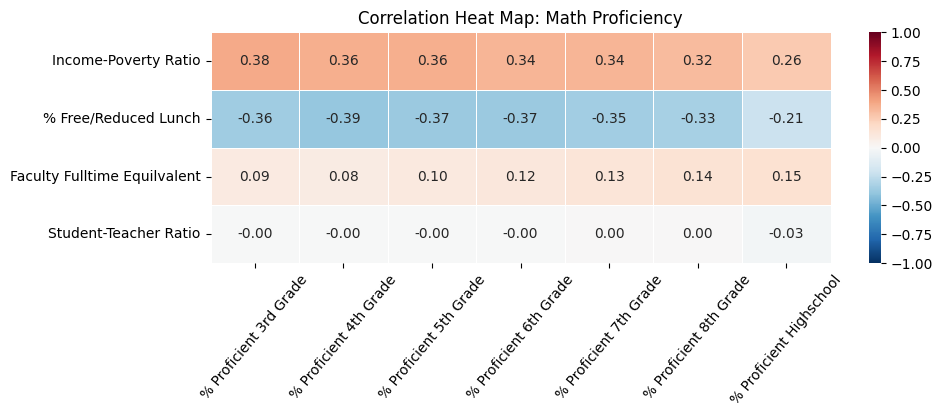

In [ ]:
df_combined_math["pct_total_free_reduced_lunch"] = (
    df_combined_math["total_free_reduced_lunch"] /
    df_combined_math["total_students"]
)

df_mathcorr = df_combined_math[['pct_total_free_reduced_lunch',
                                'income_to_poverty_ratio_estimate',
                                'facualty_fulltime_equivilant',
                                'student_teacher_ratio',
              'third_proficiency',
              'fourth_proficiency',
              'fith_proficiency',
              'sixth_proficiency',
              'seventh_proficiency',
              'eighth_proficiency',
              'highschool_proficiency']]

df_mathcorr = df_mathcorr.rename(columns={
    'pct_total_free_reduced_lunch': '% Free/Reduced Lunch',
    'facualty_fulltime_equivilant': 'Faculty Fulltime Equilvalent',
    'student_teacher_ratio': 'Student-Teacher Ratio',
    'third_proficiency': '% Proficient 3rd Grade',
    'fourth_proficiency': '% Proficient 4th Grade',
    'fith_proficiency': '% Proficient 5th Grade',
    'sixth_proficiency': '% Proficient 6th Grade',
    'seventh_proficiency': '% Proficient 7th Grade',
    'eighth_proficiency': '% Proficient 8th Grade',
    'highschool_proficiency': '% Proficient Highschool',
    'income_to_poverty_ratio_estimate': 'Income-Poverty Ratio'
})

corr_matrix = df_mathcorr.corr(numeric_only=True)

corr_subset = corr_matrix.loc[
    ['Income-Poverty Ratio', '% Free/Reduced Lunch',  'Faculty Fulltime Equilvalent', 'Student-Teacher Ratio'],
    ['% Proficient 3rd Grade',
     '% Proficient 4th Grade',
     '% Proficient 5th Grade',
     '% Proficient 6th Grade',
     '% Proficient 7th Grade',
     '% Proficient 8th Grade',
     '% Proficient Highschool']
]

plt.figure(figsize=(10,3))

sns.heatmap(
    corr_subset,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Correlation Heat Map: Math Proficiency")
plt.xticks(rotation=50)



Text(0.5, 1.0, 'Correlation Heat Map: Math Proficiency')

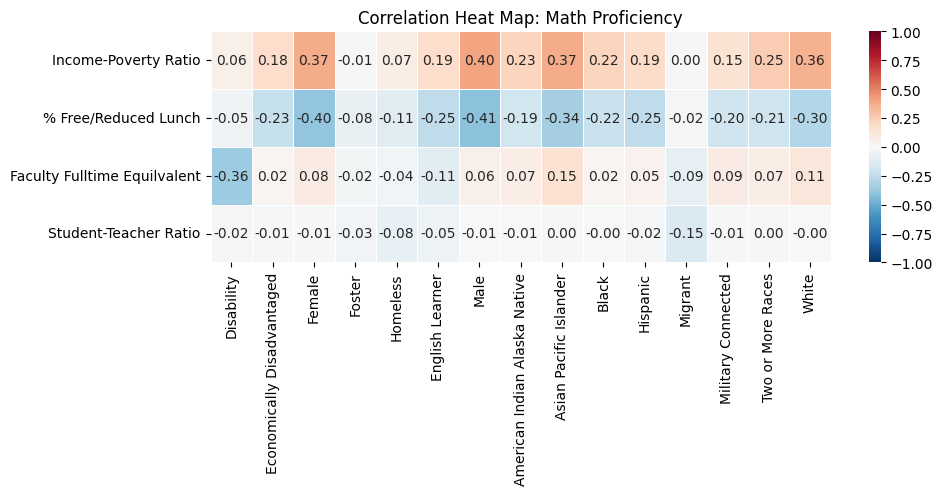

In [ ]:
df_mathcorr2 = df_combined_math[['pct_total_free_reduced_lunch',
                                'income_to_poverty_ratio_estimate',
                                'facualty_fulltime_equivilant',
                                'student_teacher_ratio',
    'dissability_proficiency',
    'economically_disadvantaged_proficiency',
    'female_proficiency',
    'foster_proficiency',
    'homeless_proficiency',
    'english_learner_proficiency',
    'male_proficiency',
    'american_indian_alaska_native_proficiency',
    'asian_pacific_islander_proficiency',
    'black_proficiency',
    'hispanic_proficiency',
    'migrant_proficiency',
    'military_connected_proficiency',
    'two_or_more_race_proficiency',
    'white_proficiency'
]]

df_mathcorr2 = df_mathcorr2.rename(columns={
    'pct_total_free_reduced_lunch': '% Free/Reduced Lunch',
    'facualty_fulltime_equivilant': 'Faculty Fulltime Equilvalent',
    'student_teacher_ratio': 'Student-Teacher Ratio',
    'income_to_poverty_ratio_estimate': 'Income-Poverty Ratio',
    'dissability_proficiency' : 'Disability',
    'economically_disadvantaged_proficiency' : 'Economically Disadvantaged',
    'female_proficiency' : 'Female',
    'foster_proficiency' : 'Foster',
    'homeless_proficiency' : 'Homeless',
    'english_learner_proficiency' : 'English Learner',
    'male_proficiency' : 'Male',
    'american_indian_alaska_native_proficiency' : 'American Indian Alaska Native',
    'asian_pacific_islander_proficiency' : 'Asian Pacific Islander',
    'black_proficiency' : 'Black',
    'hispanic_proficiency' : 'Hispanic',
    'migrant_proficiency' : 'Migrant',
    'military_connected_proficiency' : 'Military Connected',
    'two_or_more_race_proficiency' : 'Two or More Races',
    'white_proficiency' : 'White'
})

corr_matrix = df_mathcorr2.corr(numeric_only=True)

corr_subset = corr_matrix.loc[
    ['Income-Poverty Ratio', '% Free/Reduced Lunch',  'Faculty Fulltime Equilvalent', 'Student-Teacher Ratio'],
    ['Disability',
    'Economically Disadvantaged',
    'Female',
    'Foster',
    'Homeless',
    'English Learner',
    'Male',
    'American Indian Alaska Native',
    'Asian Pacific Islander',
    'Black',
    'Hispanic',
    'Migrant',
    'Military Connected',
    'Two or More Races',
    'White']
]

plt.figure(figsize=(10,3))

sns.heatmap(
    corr_subset,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heat Map: Math Proficiency")


In [ ]:
df_combined_RLA = pd.read_sql("""
    SELECT *
    FROM public_schools ps
    LEFT JOIN poverty_estimates pe
      ON ps.school_id = pe.school_id
    LEFT JOIN reading_language_arts rla
      ON ps.school_id = rla.school_id
""", db)
df_combined_RLA = df_combined.loc[:, ~df_combined.columns.duplicated()]

/tmp/ipykernel_189/1119421297.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_RLA["pct_total_free_reduced_lunch"] = (


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0.5, 0, '% Proficient 3rd Grade'),
  Text(1.5, 0, '% Proficient 4th Grade'),
  Text(2.5, 0, '% Proficient 5th Grade'),
  Text(3.5, 0, '% Proficient 6th Grade'),
  Text(4.5, 0, '% Proficient 7th Grade'),
  Text(5.5, 0, '% Proficient 8th Grade'),
  Text(6.5, 0, '% Proficient Highschool')])

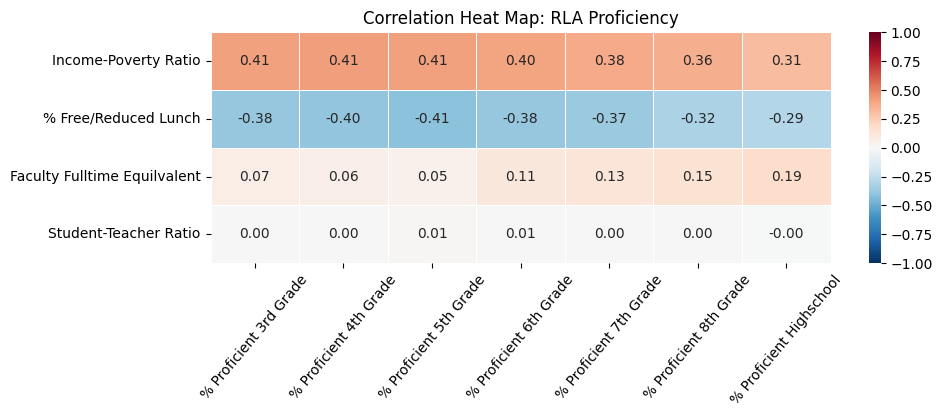

In [ ]:
df_combined_RLA["pct_total_free_reduced_lunch"] = (
    df_combined_RLA["total_free_reduced_lunch"]/
    df_combined_RLA["total_students"])

df_RLAcorr = df_combined_RLA[['pct_total_free_reduced_lunch',
                                'income_to_poverty_ratio_estimate',
                                'facualty_fulltime_equivilant',
                                'student_teacher_ratio',
              'third_proficiency',
              'fourth_proficiency',
              'fith_proficiency',
              'sixth_proficiency',
              'seventh_proficiency',
              'eighth_proficiency',
              'highschool_proficiency']]

df_RLAcorr = df_RLAcorr.rename(columns={
    'pct_total_free_reduced_lunch': '% Free/Reduced Lunch',
    'facualty_fulltime_equivilant': 'Faculty Fulltime Equilvalent',
    'student_teacher_ratio': 'Student-Teacher Ratio',
    'third_proficiency': '% Proficient 3rd Grade',
    'fourth_proficiency': '% Proficient 4th Grade',
    'fith_proficiency': '% Proficient 5th Grade',
    'sixth_proficiency': '% Proficient 6th Grade',
    'seventh_proficiency': '% Proficient 7th Grade',
    'eighth_proficiency': '% Proficient 8th Grade',
    'highschool_proficiency': '% Proficient Highschool',
    'income_to_poverty_ratio_estimate': 'Income-Poverty Ratio'
})

corr_matrix = df_RLAcorr.corr(numeric_only=True)

corr_subset = corr_matrix.loc[
    ['Income-Poverty Ratio', '% Free/Reduced Lunch',  'Faculty Fulltime Equilvalent', 'Student-Teacher Ratio'],
    ['% Proficient 3rd Grade',
     '% Proficient 4th Grade',
     '% Proficient 5th Grade',
     '% Proficient 6th Grade',
     '% Proficient 7th Grade',
     '% Proficient 8th Grade',
     '% Proficient Highschool']
]

plt.figure(figsize=(10,3))

sns.heatmap(
    corr_subset,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Correlation Heat Map: RLA Proficiency")
plt.xticks(rotation=50)

Text(0.5, 1.0, 'Correlation Heat Map: RLA Proficiency')

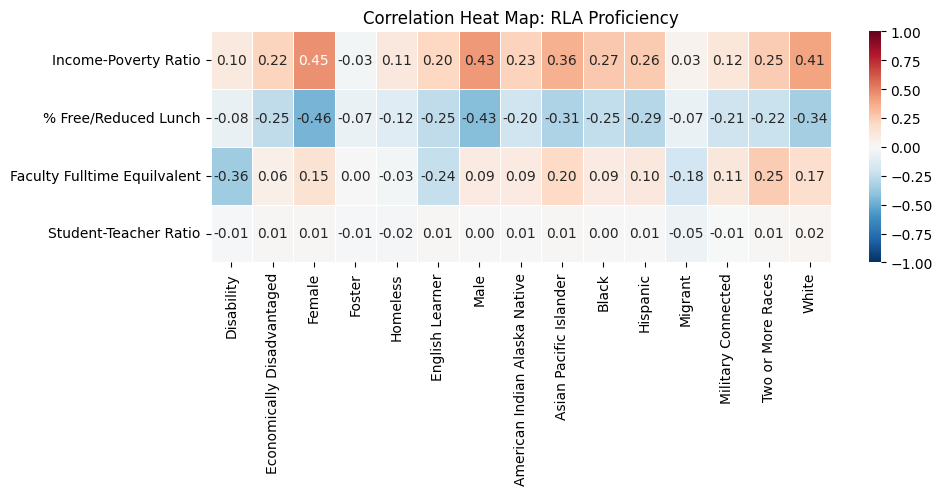

In [ ]:
df_RLAcorr2 = df_combined_RLA[['pct_total_free_reduced_lunch',
                                'income_to_poverty_ratio_estimate',
                                'facualty_fulltime_equivilant',
                                'student_teacher_ratio',
    'dissability_proficiency',
    'economically_disadvantaged_proficiency',
    'female_proficiency',
    'foster_proficiency',
    'homeless_proficiency',
    'english_learner_proficiency',
    'male_proficiency',
    'american_indian_alaska_native_proficiency',
    'asian_pacific_islander_proficiency',
    'black_proficiency',
    'hispanic_proficiency',
    'migrant_proficiency',
    'military_connected_proficiency',
    'two_or_more_race_proficiency',
    'white_proficiency'
]]

df_RLAcorr2 = df_RLAcorr2.rename(columns={
    'pct_total_free_reduced_lunch': '% Free/Reduced Lunch',
    'facualty_fulltime_equivilant': 'Faculty Fulltime Equilvalent',
    'student_teacher_ratio': 'Student-Teacher Ratio',
    'income_to_poverty_ratio_estimate': 'Income-Poverty Ratio',
    'dissability_proficiency' : 'Disability',
    'economically_disadvantaged_proficiency' : 'Economically Disadvantaged',
    'female_proficiency' : 'Female',
    'foster_proficiency' : 'Foster',
    'homeless_proficiency' : 'Homeless',
    'english_learner_proficiency' : 'English Learner',
    'male_proficiency' : 'Male',
    'american_indian_alaska_native_proficiency' : 'American Indian Alaska Native',
    'asian_pacific_islander_proficiency' : 'Asian Pacific Islander',
    'black_proficiency' : 'Black',
    'hispanic_proficiency' : 'Hispanic',
    'migrant_proficiency' : 'Migrant',
    'military_connected_proficiency' : 'Military Connected',
    'two_or_more_race_proficiency' : 'Two or More Races',
    'white_proficiency' : 'White'
})

corr_matrix = df_RLAcorr2.corr(numeric_only=True)

corr_subset = corr_matrix.loc[
    ['Income-Poverty Ratio', '% Free/Reduced Lunch',  'Faculty Fulltime Equilvalent', 'Student-Teacher Ratio'],
    ['Disability',
    'Economically Disadvantaged',
    'Female',
    'Foster',
    'Homeless',
    'English Learner',
    'Male',
    'American Indian Alaska Native',
    'Asian Pacific Islander',
    'Black',
    'Hispanic',
    'Migrant',
    'Military Connected',
    'Two or More Races',
    'White']
]

plt.figure(figsize=(10,3))

sns.heatmap(
    corr_subset,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heat Map: RLA Proficiency")


In [ ]:
df_combined_grad = pd.read_sql("""
    SELECT *
    FROM public_schools ps
    LEFT JOIN poverty_estimates pe
      ON ps.school_id = pe.school_id
    LEFT JOIN graduation_rates gr
      ON ps.school_id = gr.school_id
""", db)

# Removed the line below which was overwriting df_combined_grad with df_combined.
# If deduplication is needed for df_combined_grad specifically, it should be applied here:
# df_combined_grad = df_combined_grad.loc[:, ~df_combined_grad.columns.duplicated()]

Text(0.5, 1.0, 'Correlation Heat Map: Graduation Rates')

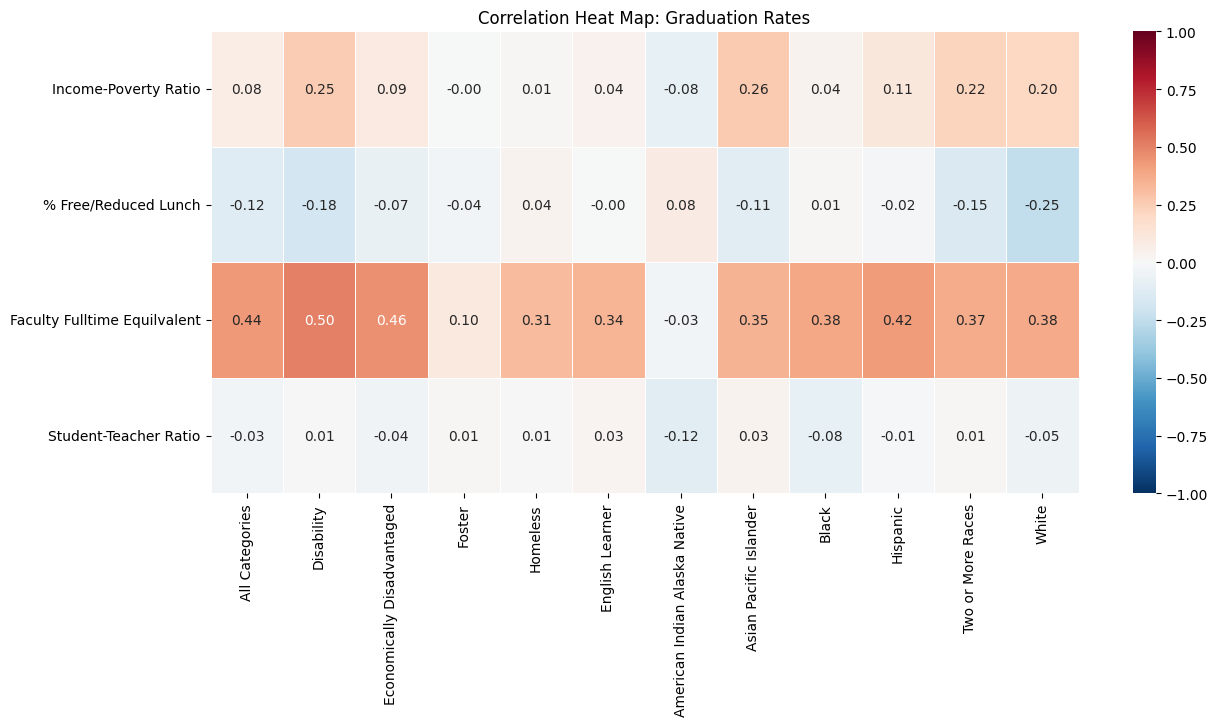

In [ ]:
df_combined_grad["pct_total_free_reduced_lunch"] = (
    df_combined_grad["total_free_reduced_lunch"]/
    df_combined_grad["total_students"])

df_combined_grad_corr = df_combined_grad[['pct_total_free_reduced_lunch',
                                'income_to_poverty_ratio_estimate',
                                'facualty_fulltime_equivilant',
                                'student_teacher_ratio',
                                          'all_categories_graduation',
                                          'dissability_graduation',
                                          'economically_disadvantaged_graduation',
                                          'foster_graduation',
                                          'homeless_graduation',
                                          'english_learner_graduation',
                                          'american_indian_alaska_native_graduation',
                                          'asian_pacific_islander_graduation',
                                          'black_graduation',
                                          'hispanic_graduation',
                                          'two_or_more_race_graduation',
                                          'white_graduation']]

df_combined_grad_corr = df_combined_grad_corr.rename(columns={
    'pct_total_free_reduced_lunch': '% Free/Reduced Lunch',
    'facualty_fulltime_equivilant': 'Faculty Fulltime Equilvalent',
    'student_teacher_ratio': 'Student-Teacher Ratio',
    'income_to_poverty_ratio_estimate': 'Income-Poverty Ratio',
    'all_categories_graduation' : 'All Categories',
    'dissability_graduation' : 'Disability',
    'economically_disadvantaged_graduation' : 'Economically Disadvantaged',
    'foster_graduation' : 'Foster',
    'homeless_graduation' : 'Homeless',
    'english_learner_graduation' : 'English Learner',
    'american_indian_alaska_native_graduation' : 'American Indian Alaska Native',
    'asian_pacific_islander_graduation' : 'Asian Pacific Islander',
    'black_graduation' : 'Black',
    'hispanic_graduation' : 'Hispanic',
    'two_or_more_race_graduation' : 'Two or More Races',
    'white_graduation' : 'White'
})

corr_matrix = df_combined_grad_corr.corr(numeric_only=True)

corr_subset = corr_matrix.loc[
    ['Income-Poverty Ratio', '% Free/Reduced Lunch',  'Faculty Fulltime Equilvalent', 'Student-Teacher Ratio'],
    ['All Categories',
                                          'Disability',
                                          'Economically Disadvantaged',
                                          'Foster',
                                          'Homeless',
                                          'English Learner',
                                          'American Indian Alaska Native',
                                          'Asian Pacific Islander',
                                          'Black',
                                          'Hispanic',
                                          'Two or More Races',
                                          'White']
]

plt.figure(figsize=(14,6))

sns.heatmap(
    corr_subset,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Correlation Heat Map: Graduation Rates")

/tmp/ipykernel_189/3124904970.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


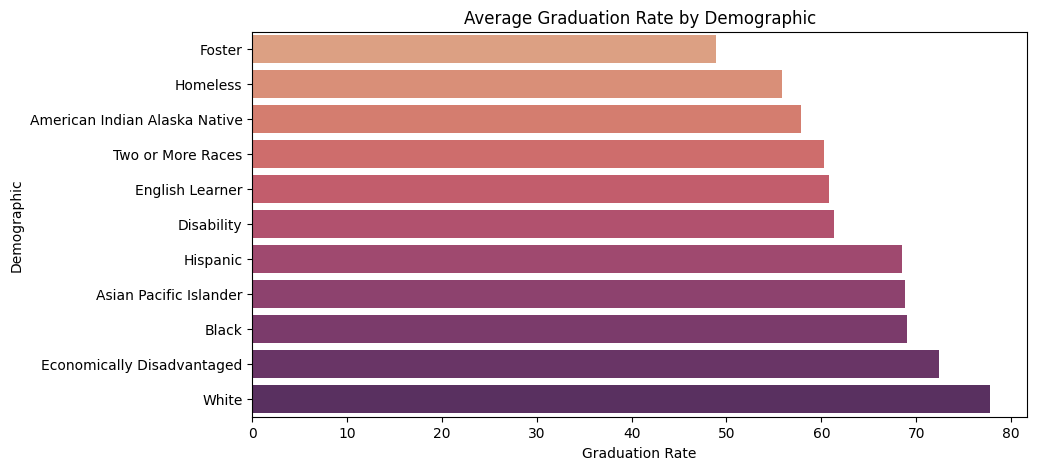

In [ ]:
race_grad = df_combined_grad[[
    'dissability_graduation',
    'economically_disadvantaged_graduation',
    'foster_graduation',
    'homeless_graduation',
    'english_learner_graduation',
    'american_indian_alaska_native_graduation',
    'asian_pacific_islander_graduation',
    'black_graduation',
    'hispanic_graduation',
    'two_or_more_race_graduation',
    'white_graduation'
]]

race_grad = race_grad.rename(columns={
    'dissability_graduation' : 'Disability',
    'economically_disadvantaged_graduation' : 'Economically Disadvantaged',
    'foster_graduation' : 'Foster',
    'homeless_graduation' : 'Homeless',
    'english_learner_graduation' : 'English Learner',
    'american_indian_alaska_native_graduation' : 'American Indian Alaska Native',
    'asian_pacific_islander_graduation' : 'Asian Pacific Islander',
    'black_graduation' : 'Black',
    'hispanic_graduation' : 'Hispanic',
    'two_or_more_race_graduation' : 'Two or More Races',
    'white_graduation' : 'White'
})

race_avg = race_grad.mean().sort_values()
race_avg_df = race_avg.reset_index()
race_avg_df.columns = ["Demographic", "Graduation Rate"]

plt.figure(figsize=(10,5))

sns.barplot(
    data=race_avg_df,
    x="Graduation Rate",
    y="Demographic",
    palette = "flare"
)

plt.title("Average Graduation Rate by Demographic")
plt.show()

/tmp/ipykernel_189/3420555568.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


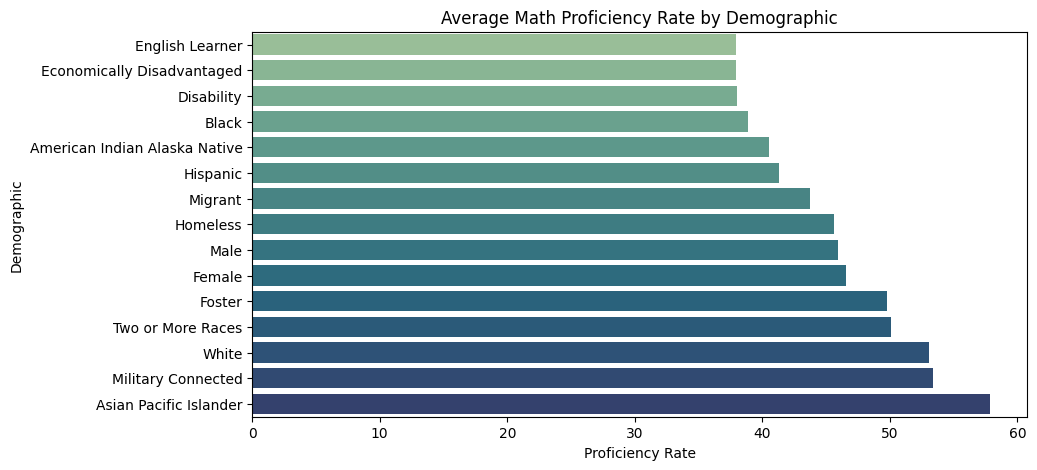

In [ ]:
demographic_math = df_combined_math[[
    'dissability_proficiency',
    'economically_disadvantaged_proficiency',
    'female_proficiency',
    'foster_proficiency',
    'homeless_proficiency',
    'english_learner_proficiency',
    'male_proficiency',
    'american_indian_alaska_native_proficiency',
    'asian_pacific_islander_proficiency',
    'black_proficiency',
    'hispanic_proficiency',
    'migrant_proficiency',
    'military_connected_proficiency',
    'two_or_more_race_proficiency',
    'white_proficiency'
]]

demographic_math = demographic_math.rename(columns={
    'dissability_proficiency' : 'Disability',
    'economically_disadvantaged_proficiency' : 'Economically Disadvantaged',
    'female_proficiency' : 'Female',
    'foster_proficiency' : 'Foster',
    'homeless_proficiency' : 'Homeless',
    'english_learner_proficiency' : 'English Learner',
    'male_proficiency' : 'Male',
    'american_indian_alaska_native_proficiency' : 'American Indian Alaska Native',
    'asian_pacific_islander_proficiency' : 'Asian Pacific Islander',
    'black_proficiency' : 'Black',
    'hispanic_proficiency' : 'Hispanic',
    'migrant_proficiency' : 'Migrant',
    'military_connected_proficiency' : 'Military Connected',
    'two_or_more_race_proficiency' : 'Two or More Races',
    'white_proficiency' : 'White'
})

demographic_math_avg = demographic_math.mean().sort_values()
demographic_math_avg_df = demographic_math_avg.reset_index()
demographic_math_avg_df.columns = ["Demographic", "Proficiency Rate"]

plt.figure(figsize=(10,5))

sns.barplot(
    data=demographic_math_avg_df,
    x="Proficiency Rate",
    y="Demographic",
    palette = "crest"
)

plt.title("Average Math Proficiency Rate by Demographic")
plt.show()

/tmp/ipykernel_189/2942527772.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


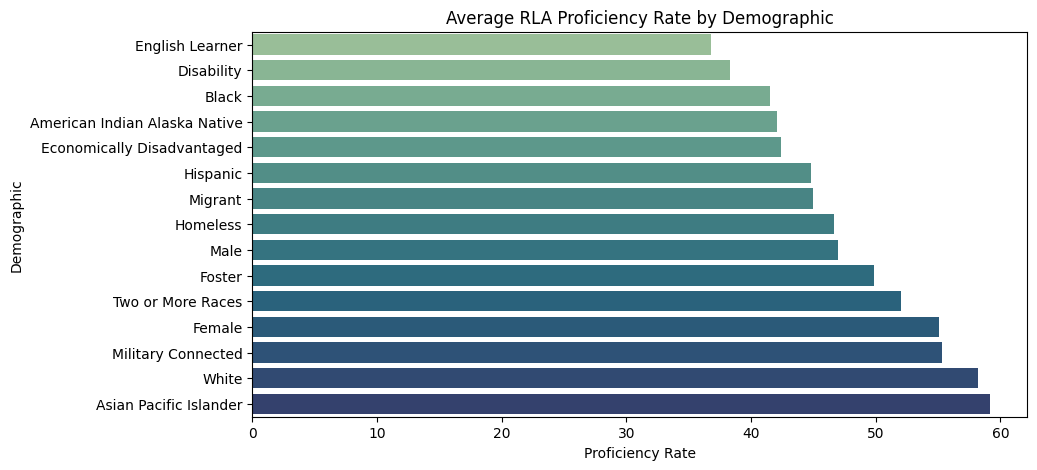

In [ ]:
demographic_RLA = df_combined_RLA[[
    'dissability_proficiency',
    'economically_disadvantaged_proficiency',
    'female_proficiency',
    'foster_proficiency',
    'homeless_proficiency',
    'english_learner_proficiency',
    'male_proficiency',
    'american_indian_alaska_native_proficiency',
    'asian_pacific_islander_proficiency',
    'black_proficiency',
    'hispanic_proficiency',
    'migrant_proficiency',
    'military_connected_proficiency',
    'two_or_more_race_proficiency',
    'white_proficiency'
]]

demographic_RLA = demographic_RLA.rename(columns={
    'dissability_proficiency' : 'Disability',
    'economically_disadvantaged_proficiency' : 'Economically Disadvantaged',
    'female_proficiency' : 'Female',
    'foster_proficiency' : 'Foster',
    'homeless_proficiency' : 'Homeless',
    'english_learner_proficiency' : 'English Learner',
    'male_proficiency' : 'Male',
    'american_indian_alaska_native_proficiency' : 'American Indian Alaska Native',
    'asian_pacific_islander_proficiency' : 'Asian Pacific Islander',
    'black_proficiency' : 'Black',
    'hispanic_proficiency' : 'Hispanic',
    'migrant_proficiency' : 'Migrant',
    'military_connected_proficiency' : 'Military Connected',
    'two_or_more_race_proficiency' : 'Two or More Races',
    'white_proficiency' : 'White'
})

demographic_RLA_avg = demographic_RLA.mean().sort_values()
demographic_RLA_avg_df = demographic_RLA_avg.reset_index()
demographic_RLA_avg_df.columns = ["Demographic", "Proficiency Rate"]

plt.figure(figsize=(10,5))

sns.barplot(
    data=demographic_RLA_avg_df,
    x="Proficiency Rate",
    y="Demographic",
    palette = "crest"
)

plt.title("Average RLA Proficiency Rate by Demographic")
plt.show()